## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA

import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from os.path import join
import pandas as pd
np.random.seed(0)

In [2]:
# data_path = '/home/lqr/CLIMA/datasets/skin_sample/'
# gene = pd.read_csv(join(data_path, 'GSE140203_mouse_skin_Gene_normalized_downsampling.csv'), index_col=0)
# peak = pd.read_csv(join(data_path, 'GSE140203_mouse_skin_PeakonGene_normalized_downsampling.csv'), index_col=0)

# np.savez(join(data_path, 'skin_normalized.npz'), gene=gene.values, peak=peak.values)

In [3]:

data_path = '/home/lqr/CLIMA/datasets/skin_sample/'
data = np.load(join(data_path, 'skin_normalized.npz'))
gene = data['gene']
peak = data['peak']
# data1 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_Gene_counts.csv'), index_col=0)
# data2 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_PeakonGene_counts.csv'), index_col=0)
# data1 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_Gene_normalized.csv'), index_col=0)
# data2 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_PeakonGene_normalized.csv'), index_col=0)



In [4]:
gene_peak = gene * peak
# gene_peak = gene + peak
# gene_peak = (gene + 1) * (peak + 1)

## Generate simulation data

In [5]:
print(f"gene_sum: {np.sum(gene)}")
print(f"peak_sum: {np.sum(peak)}")
# 找出所有值都为空的列
gene_empty_cols = np.all(gene == 0, axis=0)
peak_empty_cols = np.all(peak == 0, axis=0)
print(f"gene_empty_cols: {np.sum(gene_empty_cols)}")
print(f"peak_empty_cols: {np.sum(peak_empty_cols)}")

gene_sum: 7051835.70186944
peak_sum: 1639058.7600096497
gene_empty_cols: 2798
peak_empty_cols: 21837



Simulation parameters



Use simulation tool to generate multi-modality data

## Analyses based on single modality

Learn features from single modality

In [6]:
latent_dim = 100
view_gene_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene)
view_peak_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(peak)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(gene_peak)

In [7]:
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")
print(f"view_gene_feature.shape: {view_gene_feature.shape}")
print(f"view_peak_feature.shape: {view_peak_feature.shape}")

gene.shape: (4531, 23296)
peak.shape: (4531, 23296)
view_gene_feature.shape: (4531, 100)
view_peak_feature.shape: (4531, 100)


Perform clustering using PhenoGraph

In [8]:
view_a_label, _, _ = phenograph.cluster(view_gene_feature)
view_b_label, _, _ = phenograph.cluster(view_peak_feature)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.14681220054626465 seconds
Jaccard graph constructed in 0.6036441326141357 seconds
Wrote graph to binary file in 0.022387266159057617 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.800899
After 2 runs, maximum modularity is Q = 0.802906
Louvain completed 22 runs in 1.8786754608154297 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 3.174938201904297 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09734773635864258 seconds
Jaccard graph constructed in 0.6128809452056885 seconds
Wrote graph to binary file in 0.02178335189819336 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.589477
After 3 runs, maximum modularity is Q = 0.591228
After 8 runs, maximum modularity is Q = 0.592408
Louvain completed 28 runs in 2.393340826034546 se

In [9]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_gene_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_peak_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

X_embedded: (4531, 2)
label_true: (4531,)


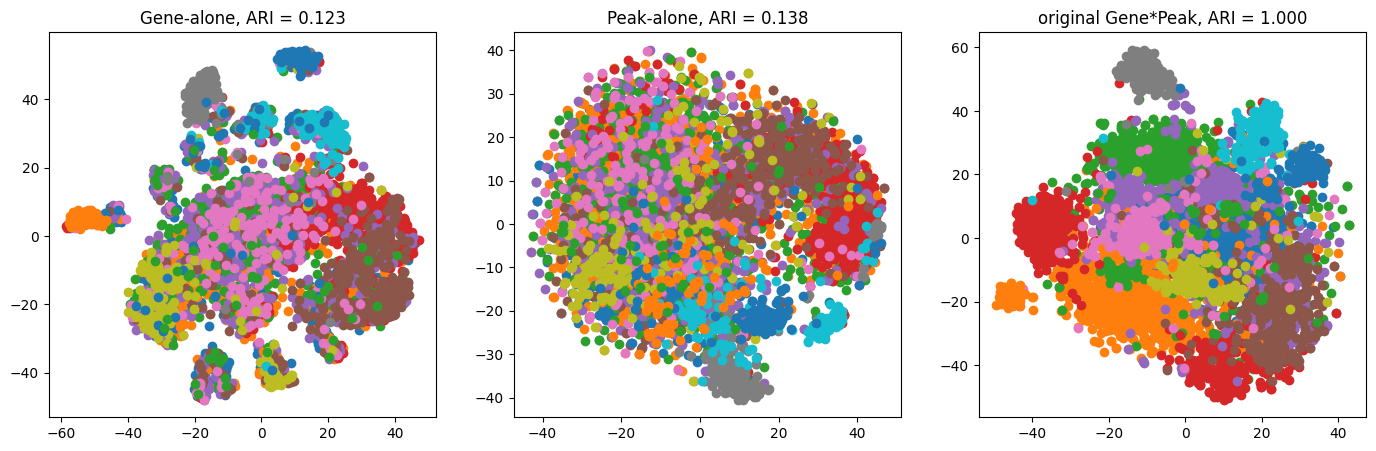

In [10]:
plt.figure(figsize=(17, 5))
# Gene-alone
plt.subplot(1, 3, 1)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {view_ab_label.shape}")
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Gene-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

# Peak-alone
plt.subplot(1, 3, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('Peak-alone, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

# original Gene+Peak
plt.subplot(1, 3, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('original Gene*Peak, ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [11]:
outputs = muse.dual_muse_fit_predict(
    [gene, peak],
    [gene_peak],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=5,
    weight_penalty=1,
    triplet_lambda=5,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++


#epoch: 0/200 	 total loss: 263.19 	 sc loss: 141.91 	 st loss: 101.34 	 infoNCE: 19.94 	 sc recon: 0.12 	 st recon: 2.02 	 sc sparse: 141.79 	 st sparse: 99.32 	 sc trip: 0.00 	 st trip: 0.00


KeyboardInterrupt: 

In [94]:
latent_sc = (outputs[0])
latent_st = (outputs[1])
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (4531, 100)
latent_st: (4531, 100)
reconstruct_sc: (2, 4531, 23296)
reconstruct_st: (1, 4531, 23296)
encoded_sc: (2, 4531, 128)
encoded_st: (1, 4531, 128)


## Perform clustering
PhenoGraph clustering

In [95]:
latent_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
latent_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09989309310913086 seconds
Jaccard graph constructed in 0.8760795593261719 seconds
Wrote graph to binary file in 0.020486831665039062 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.697377
After 2 runs, maximum modularity is Q = 0.699309
After 3 runs, maximum modularity is Q = 0.702098
After 4 runs, maximum modularity is Q = 0.703487
Louvain completed 24 runs in 2.950343132019043 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 4.702280044555664 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0947260856628418 seconds
Jaccard graph constructed in 0.8352055549621582 seconds
Wrote graph to binary file in 0.01823258399963379 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.903371
Louvain completed 21 runs in 1.7707650661468506 sec

## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [96]:
latent_X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
latent_Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

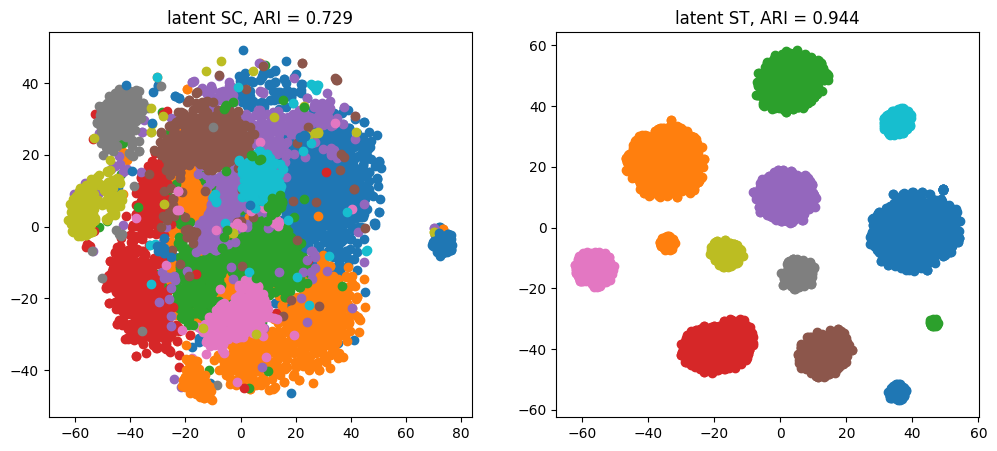

In [97]:
plt.figure(figsize=(12, 5))
# Gene, Peak MUSE(latent sc)
plt.subplot(1, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(latent_X_embedded[idx, 0], latent_X_embedded[idx, 1])
    plt.title('latent SC, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_sc))

# Peak+Gene MUSE(latent st)
plt.subplot(1, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(latent_Y_embedded[idx, 0], latent_Y_embedded[idx, 1])
    plt.title('latent ST, ARI = %01.3f' % adjusted_rand_score(view_ab_label, latent_label_st))

plt.show()

In [98]:
print('[gene, peak] and [gene+peak] ARI: ', adjusted_rand_score(latent_label_sc, latent_label_st))

[gene, peak] and [gene+peak] ARI:  0.6971121859402777


**************************************************
S: torch.Size([4531, 100, 1])
G: torch.Size([4531, 100, 1])


 14%|█▍        | 72/500 [00:00<00:02, 176.85it/s]

Epoch 50: Loss -0.9797178506851196


 25%|██▌       | 126/500 [00:00<00:02, 176.69it/s]

Epoch 100: Loss -1.4422540664672852


...

Epoch 400: Loss -1.6133140325546265


 94%|█████████▎| 468/500 [00:02<00:00, 176.16it/s]

Epoch 450: Loss -1.614903211593628


100%|██████████| 500/500 [00:02<00:00, 176.11it/s]


Epoch 500: Loss -1.6161420345306396
[[13.782094    2.1077752   3.1899261  ... -2.2402375   0.83705115
  -2.3747196 ]
 [-0.49406812 13.786901    2.293677   ...  0.33267602  2.13796
   0.1716424 ]
 [ 1.9893093   0.6375395  13.580766   ...  3.0531037  -1.9678829
  -1.691983  ]
 ...
 [ 0.75585544 -0.52052855  1.5876062  ... -1.5927004  -0.38713756
   0.88344485]
 [-1.465955    1.2422895  -0.9528143  ... -1.3490751  14.0352545
  -0.3440982 ]
 [-1.9652078  -2.7119975  -1.7443424  ...  1.0741501   2.5113025
  13.936516  ]]


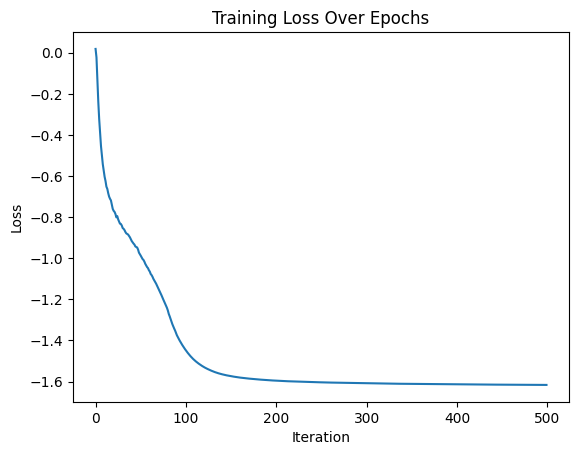

In [99]:
from sim_tangram.train_tangram import read_csv_and_run_tangram
import torch

# tangram
tangram_sim, _ = read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    # [torch.tensor(view_c_feature, device='cuda:0', dtype=torch.float32)],
    # [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=50,
    lambda_g1=1,
    lambda_g2=1
)

**************************************************
S: torch.Size([4531, 100, 1])
G: torch.Size([4531, 100, 1])


100%|██████████| 500/500 [00:01<00:00, 288.49it/s]

Epoch 500: Loss -0.7774677276611328
[[13.918476    2.47782     1.4641845  ... -1.9895633   0.7865959
  -1.9446979 ]
 [-0.14669955 14.123622    2.0191054  ...  0.2746534   2.3374047
  -1.2156407 ]
 [ 0.8954173   2.3551862  13.988015   ... -0.06042647 -1.7223594
  -1.562175  ]
 ...
 [-0.34415784 -0.20411196 -0.5535105  ... -1.7853605  -0.41119343
  -1.2736547 ]
 [-1.526023    2.0522828  -0.66941583 ... -1.2748785  14.243815
  -0.2433083 ]
 [-1.6340647  -2.6098135  -1.4734944  ... -0.50832057  2.7270324
  14.313881  ]]


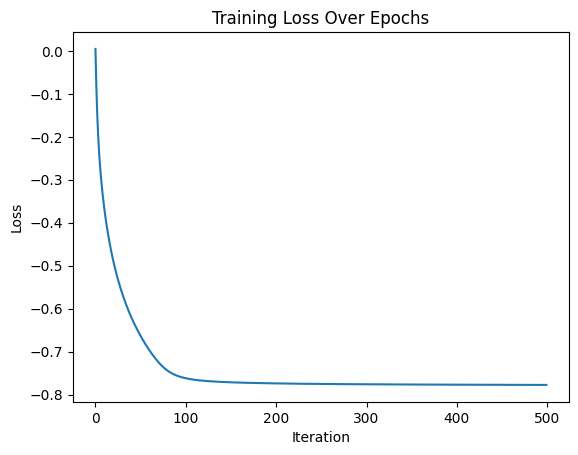

In [100]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=0,
)

In [101]:
# tangram cosine_similarity
cos_tg_mapping = cos_sim_tg.argmax(axis=1)

# tangram cca
mapping = tangram_sim.argmax(axis=1)
for i in range(len(mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {mapping[i]:4d}", end="\t")
# cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	

In [102]:
sample_size = tangram_sim.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
tangram_acc = np.sum(mapping == gt) / sample_size
print("tangram accuracy:", tangram_acc)
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 0.9916133303906423
tangram accuracy: 0.9706466563672479
cos_tg accuracy: 0.9382034870889429
